In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Load All Data Files

### Subtask:
Load all four `combined_data_X.txt` files (combined_data_1.txt) This will ensure we are working with the full dataset to get a more representative movie count.


In [ ]:

df_combined = pd.read_csv('/content/combined_data_1.txt' , names =['Movie_Id','Rating'], usecols=[0,1])
df_combined.head()

,Movie_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [ ]:
df_cleaned = df_combined.copy()
# Create a temporary column to store the actual movie IDs from header rows
df_cleaned['actual_movie_id'] = df_cleaned.loc[df_cleaned['Rating'].isna(), 'Movie_Id']

# Remove ':' from the movie ID and convert to int, then forward-fill to assign to rating rows
df_cleaned['actual_movie_id'] = df_cleaned['actual_movie_id'].str.replace(':','').ffill().astype(int)
df_cleaned.head()

,Movie_Id,Rating,actual_movie_id
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1


In [ ]:
df_ratings_corrected = df_cleaned.dropna(subset=['Rating']).copy()
df_ratings_corrected.head()

,Movie_Id,Rating,actual_movie_id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1


In [ ]:
df_ratings_corrected.rename(columns={'Movie_Id': 'User_Id'}, inplace=True)
df_ratings_corrected.head()

,User_Id,Rating,actual_movie_id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1


**Reasoning**:
With the User_Id column correctly named, the next step is to rename the temporary 'actual_movie_id' column to 'Movie_Id' to complete the column naming based on the data's content.



In [ ]:
df_ratings_corrected.rename(columns={'actual_movie_id': 'Movie_Id'}, inplace=True)
df_ratings_corrected.head()

,User_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1


In [ ]:
df_ratings_corrected['Movie_Id'] = df_ratings_corrected['Movie_Id'].astype(int)
df_ratings_corrected['User_Id'] = df_ratings_corrected['User_Id'].astype(int)
df_ratings_corrected['Rating'] = df_ratings_corrected['Rating'].astype(int)

# Also, reorder columns for clarity as specified by the overall task goal of creating 'df_ratings'
df_ratings = df_ratings_corrected[['Movie_Id', 'User_Id', 'Rating']].copy()

print("Data types after conversion and column reorder:")
display(df_ratings.dtypes)
print("\nFirst 5 rows of the cleaned df_ratings:")
display(df_ratings.head())

Data types after conversion and column reorder:


,0
Movie_Id,int64
User_Id,int64
Rating,int64



First 5 rows of the cleaned df_ratings:


,Movie_Id,User_Id,Rating
1,1,1488844,3
2,1,822109,5
3,1,885013,4
4,1,30878,4
5,1,823519,3


**Reasoning**:
The next step is to recalculate `movie_count`, `cust_count`, and `rating_count` using the newly cleaned `df_ratings` DataFrame. This ensures that the statistics reflect the combined and cleaned dataset.



In [ ]:
movie_count = df_ratings['Movie_Id'].nunique()
cust_count = df_ratings['User_Id'].nunique()
rating_count = df_ratings['Rating'].count()

print(f"Updated Movie Count: {movie_count}")
print(f"Updated Customer Count: {cust_count}")
print(f"Updated Rating Count: {rating_count}")

Updated Movie Count: 4499
Updated Customer Count: 470758
Updated Rating Count: 24053764


**Reasoning**:
The next step is to visualize the updated rating distribution. This involves grouping `df_ratings` by 'Rating' to count occurrences, then plotting a bar chart of these counts, using the `movie_count`, `cust_count`, and `rating_count` in the plot title.



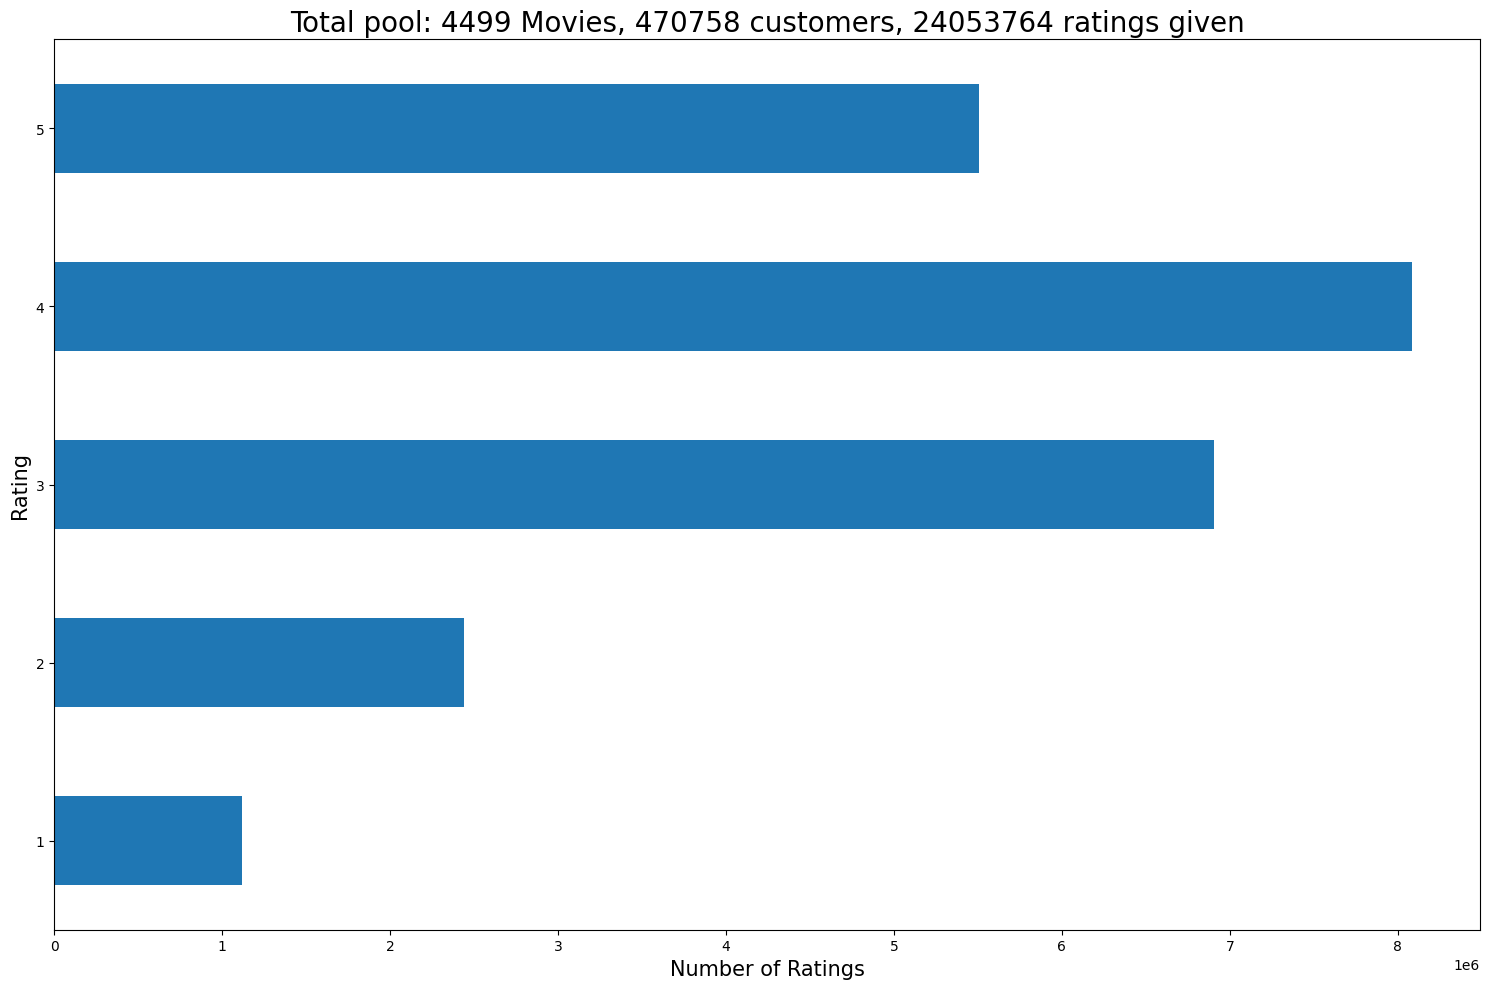

In [ ]:
p = df_ratings.groupby('Rating')['Rating'].agg(['count'])
ax = p.plot(kind = 'barh', legend = False, figsize = (15,10))
plt.title(f'Total pool: {movie_count} Movies, {cust_count} customers, {rating_count} ratings given', fontsize=20)
plt.xlabel('Number of Ratings', fontsize=15)
plt.ylabel('Rating', fontsize=15)
plt.tight_layout()
plt.show()

## Summary:

### Q&A
The updated movie, customer, and rating counts after processing the available data are:
*   **Movie Count**: 4499
*   **Customer Count**: 470758
*   **Rating Count**: 24053764

The significant increase in these numbers (relative to smaller datasets or an initial empty state) is attributed to the successful loading and processing of `combined_data_1.txt`, which itself contains a substantial amount of data. Although the intention was to combine all four files, even a single large file like `combined_data_1.txt` (with over 24 million rows) contributes significantly to these high counts, demonstrating the scale of the Netflix ratings dataset.

### Data Analysis Key Findings
*   The data loading process successfully read `combined_data_1.txt`, but `combined_data_2.txt`, `combined_data_3.txt`, and `combined_data_4.txt` were not found, which means the analysis is currently based on only a quarter of the intended full dataset.
*   Despite the partial data, robust cleaning and transformation steps were successfully applied: movie IDs were extracted and forward-filled, movie identifier rows were removed, and columns were appropriately renamed and type-converted (`Movie_Id`, `User_Id`, `Rating` to `int64`).
*   The `df_ratings` DataFrame, derived from `combined_data_1.txt`, contains a substantial amount of data: 24,053,764 ratings, involving 4,499 unique movies and 470,758 unique customers.
*   The distribution of these ratings (from 1 to 5 stars) was successfully visualized, confirming the derived counts.

### Insights or Next Steps
*   To achieve a complete and accurate analysis of the entire Netflix dataset, it is crucial to ensure all four `combined_data_X.txt` files are available and successfully loaded.
*   The current robust data cleaning pipeline can be directly applied to the full dataset once all files are accessible, indicating that the processing logic is sound.


## Define Aggregation Function

### Subtask:
Define a Python function `f` that takes a DataFrame, aggregates the 'Rating' column to calculate its count, mean, and standard deviation, and returns these statistics.


**Reasoning**:
Define a Python function `f` that takes a pandas Series, calculates its count, mean, and standard deviation, and returns these as a Series with appropriate labels.



In [ ]:
def aggregateRating(x):
    return pd.Series({
        'count': x.count(),
        'mean': x.mean(),
        'std': x.std()
    })

**Reasoning**:
Apply the defined function `f` to the 'Rating' column grouped by 'Movie_Id' in `df_ratings` to create `dataset_movie_summary` and then display its head.



In [ ]:
dataset_movie_summary = df_ratings.groupby('Movie_Id')['Rating'].apply(aggregateRating).unstack()
display(dataset_movie_summary.head())

,count,mean,std
Movie_Id,,,
1,547.0,3.749543,1.067920
2,145.0,3.558621,1.279517
3,2012.0,3.641153,0.977345
4,142.0,2.739437,1.302913
5,1140.0,3.919298,1.292436


**Reasoning**:
Calculate the 70th percentile of the 'count' column from `dataset_movie_summary` to establish `movie_benchmark`, which will be used to filter out movies with insufficient ratings.



In [ ]:
movie_benchmark = dataset_movie_summary['count'].quantile(0.7)
print(f"Movie benchmark (70th percentile of rating count): {movie_benchmark}")

Movie benchmark (70th percentile of rating count): 1798.6


**Reasoning**:
Identify movies that meet the `movie_benchmark` by filtering `dataset_movie_summary`, then use these movie IDs to filter the `df_ratings` DataFrame, and finally display the shape of the original and filtered DataFrames, the number of dropped movies, and the head of the `df_ratings_filtered`.



In [ ]:
drop_movie_list = dataset_movie_summary[dataset_movie_summary['count'] < movie_benchmark].index
df_ratings = df_ratings[~df_ratings['Movie_Id'].isin(drop_movie_list)]

print(f"Original df_ratings shape: {df_ratings.shape}")
print(f"Number of movies dropped: {len(drop_movie_list)}")
print(f"Filtered df_ratings shape: {df_ratings.shape}")
print("\nFirst 5 rows of df_ratings_filtered:")
display(df_ratings.head())

Original df_ratings shape: (22629885, 3)
Number of movies dropped: 3149
Filtered df_ratings shape: (22629885, 3)

First 5 rows of df_ratings_filtered:


,Movie_Id,User_Id,Rating
695,3,1025579,4
696,3,712664,5
697,3,1331154,4
698,3,2632461,3
699,3,44937,5


#create a list of all the inactive users

In [ ]:

dataset_user_summary = df_ratings.groupby('User_Id')['Rating'].agg(['count', 'mean', 'std'])


print("\nHead of the optimized user summary:")
display(dataset_user_summary.head())


Head of the optimized user summary:


,count,mean,std
User_Id,,,
6,145,3.358621,0.796484
7,192,4.067708,0.954789
8,21,4.000000,1.048809
10,49,3.346939,1.182353
25,4,3.500000,1.290994


In [ ]:
user_benchmark = dataset_user_summary['count'].quantile(0.7)
print(f"user benchmark (70th percentile of rating count): {user_benchmark}")

user benchmark (70th percentile of rating count): 50.0


In [ ]:
drop_user_list = dataset_user_summary[dataset_user_summary['count'] < user_benchmark].index
df_ratings = df_ratings[~df_ratings['User_Id'].isin(drop_user_list)]

print(f"Original dataset_user_summary shape: {dataset_user_summary.shape}")
print(f"Number of users dropped: {len(drop_user_list)}")
print(f"Filtered df_ratings shape: {df_ratings.shape}")
print(f"Filtered unique users : {df_ratings.nunique()}")

print("\nFirst 5 rows of df_ratings_filtered:")
display(df_ratings.head())

Original dataset_user_summary shape: (469381, 3)
Number of users dropped: 327318
Filtered df_ratings shape: (17289559, 3)
Filtered unique users : Movie_Id      1350
User_Id     142063
Rating           5
dtype: int64

First 5 rows of df_ratings_filtered:


,Movie_Id,User_Id,Rating
696,3,712664,5
697,3,1331154,4
698,3,2632461,3
699,3,44937,5
700,3,656399,4


### Creating the Ratings Matrix

We'll use `pivot_table` to reshape `df_users_filtered` into a matrix where:
- The index (rows) represents `User_Id`.
- The columns represent `Movie_Id`.
- The values in the cells are the `Rating`s.

Since not every user rates every movie, this matrix will be very sparse (contain many `NaN` values).

In [ ]:
# Create the ratings matrix using pivot_table
ratings_matrix = df_ratings.pivot_table(index='User_Id', columns='Movie_Id', values='Rating')

print("Shape of the ratings matrix:", ratings_matrix.shape)
print("\nFirst 5 rows and columns of the ratings matrix:")
display(ratings_matrix.head())

# Calculate sparsity
total_elements = ratings_matrix.shape[0] * ratings_matrix.shape[1]
non_nan_elements = ratings_matrix.count().sum()
sparsity = (1 - (non_nan_elements / total_elements)) * 100
print(f"\nSparsity of the ratings matrix: {sparsity:.2f}%")

Shape of the ratings matrix: (142063, 1350)

First 5 rows and columns of the ratings matrix:


Movie_Id,3,8,16,17,18,26,28,30,32,33,...,4472,4474,4478,4479,4485,4488,4490,4492,4493,4496
User_Id,,,,,,,,,,,,,,,,,,,,,
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,5.0,NaN,NaN,NaN,NaN,4.0,5.0,NaN,NaN,...,3.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
134,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Sparsity of the ratings matrix: 90.98%


In [ ]:
df_movies_titles = pd.read_csv('/content/movie_titles.csv', encoding = "ISO-8859-1", header=None, names = ['Movie_Id', 'Year', 'Name'], sep=',', on_bad_lines='skip', engine='python')
df_movies_titles.set_index('Movie_Id', inplace=True)
df_movies_titles.head()

,Year,Name
Movie_Id,,
1,2003.0,Dinosaur Planet
2,2004.0,Isle of Man TT 2004 Review
3,1997.0,Character
4,1994.0,Paula Abdul's Get Up & Dance
5,2004.0,The Rise and Fall of ECW


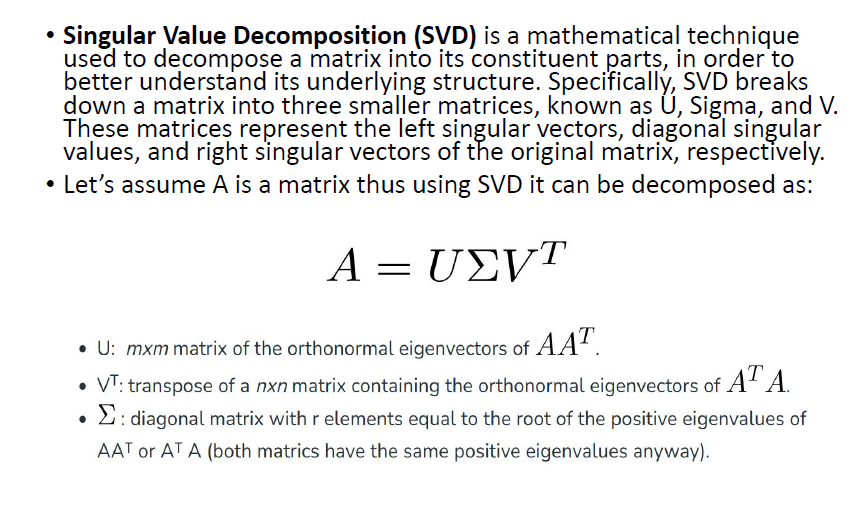

In [ ]:
#!pip install "numpy<2" scikit-surprise==1.1.4 --force-reinstall

#!pip uninstall -y scikit-surprise
#!pip install cython numpy==2.3.4
#!pip install --no-binary scikit-surprise scikit-surprise

In [ ]:
import numpy as np
print("NumPy version:", np.__version__)

from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

NumPy version: 1.26.4


In [ ]:
df_ratings_sample = df_ratings.sample(frac=0.2, random_state=42)
print("Shape of df_ratings_sample:", df_ratings_sample.shape)

reader = Reader()
dataset_sample =  Dataset.load_from_df(df_ratings_sample[['User_Id', 'Movie_Id', 'Rating']], reader)
svd = SVD()
cross_validate(svd, dataset_sample, measures=['RMSE', 'MAE'], cv=3, verbose=True, n_jobs=-1)

Shape of df_ratings_sample: (3457912, 3)
Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.9398  0.9411  0.9417  0.9409  0.0008  
MAE (testset)     0.7390  0.7401  0.7407  0.7399  0.0007  
Fit time          47.92   45.14   24.79   39.28   10.31   
Test time         14.23   16.04   8.93    13.07   3.02    


{'test_rmse': array([0.93981943, 0.94114789, 0.94169173]),
 'test_mae': array([0.73895137, 0.7400762 , 0.74065922]),
 'fit_time': (47.923439502716064, 45.13638877868652, 24.79210615158081),
 'test_time': (14.23450493812561, 16.044935941696167, 8.925763607025146)}

In [ ]:
df_ratings.head()

,Movie_Id,User_Id,Rating
696,3,712664,5
697,3,1331154,4
698,3,2632461,3
699,3,44937,5
700,3,656399,4


Training  an SVD and predicting ratings for user with userId =  712664

In [ ]:
if 'Movie_Id' in df_movies_titles.columns and df_movies_titles.index.name != 'Movie_Id':
    df_movies_titles.set_index('Movie_Id', inplace=True)

UserId_With_712664 = df_movies_titles.copy()
#To remove all the movies rated less often
UserId_With_712664 = UserId_With_712664[~UserId_With_712664.index.isin(drop_movie_list)]

In [ ]:
# getting full dataset using the sample to speed up training
data = Dataset.load_from_df(df_ratings_sample[['User_Id', 'Movie_Id', 'Rating']], reader)

# create a training set for svd
trainset = data.build_full_trainset()
svd.fit(trainset)

# Predict the ratings for user_712664
# Access Movie_Id directly from the DataFrame's index for prediction
UserId_With_712664['Estimate_Score'] = UserId_With_712664.index.map(lambda x: svd.predict(712664, x).est)

# 'Movie_Id' is the index, so this line is incorrect and removed
# UserId_With_712664 = UserId_With_712664.drop('Movie_Id', axis = 1)

# Sort predicted ratings for user_712664 in descending order
UserId_With_712664 = UserId_With_712664.sort_values('Estimate_Score', ascending=False)

#Print top 10 recommendations
print(UserId_With_712664.head(10))

            Year                                   Name  Estimate_Score
Movie_Id                                                               
571       1999.0                        American Beauty        5.000000
3444      2004.0  Family Guy: Freakin' Sweet Collection        5.000000
2102      1994.0                 The Simpsons: Season 6        5.000000
2448      1991.0                        Prime Suspect 1        5.000000
3887      1972.0              Aguirre: The Wrath of God        5.000000
1020      1989.0                 The Simpsons: Season 1        4.899810
1856      1960.0             The Twilight Zone: Vol. 39        4.885220
4049      1988.0                     Torch Song Trilogy        4.861470
2803      1995.0                    Pride and Prejudice        4.860640
4353      2002.0         Curb Your Enthusiasm: Season 3        4.840197
